## Implementation of an LSP method to automatize the building of a general oncology taxonomy
Main reference:
- Marti A. Hearst. 1992. Automatic Acquisition of Hyponyms from Large Text Corpora. In COLING 1992 Volume 2: The 14th International Conference on Computational Linguistics.

The goal is to implement a pipeline to extract hyponym-hypernym (IS-A) relations from text using the Hearst Patterns method, as described in Marti A. Hearst's paper. We will utilize the scispaCy library, which provides an implementation of the Hearst Patterns through the HyponymDetector component.
Our goal is to build a taxonomy of terms, specifically focusing on cancer-related terms, from a given text corpus.

Some observations:
- Pattern-Based Extraction: We use predefined lexico-syntactic patterns (Hearst Patterns) to extract hyponym-hypernym relations, as described in the paper.
- No Prior Lexical Knowledge: The extraction is done without relying on prior knowledge of specific terms, aligning with the method's goal of - discovering relations directly from text.
- Limitations: As observed in Hearst's paper, the method may extract relations that are too general or context-specific. Post-processing or manual validation may be necessary to refine the taxonomy.
- Automated Acquisition: The pipeline demonstrates automatic acquisition of lexical relations from a corpus, showcasing the practicality of Hearst's approach.

#### Imports
- spacy: An open-source NLP library for advanced natural language processing.
- scispacy: A spaCy extension tailored for scientific and biomedical text processing.
- HyponymDetector: A component from scispacy that implements the Hearst Patterns for hyponym-hypernym extraction.
- networkx: A Python library for creating and manipulating complex networks and graphs.
- matplotlib.pyplot: A plotting library used for visualization.

In [ ]:
import spacy
from scispacy.hyponym_detector import HyponymDetector
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
# Load the spaCy model and add the HyponymDetector to the pipeline
nlp = spacy.load("en_core_sci_sm")
nlp.add_pipe("hyponym_detector", last=True, config={"extended": False})  # Use extended=True for more patterns

In [4]:

def extract_hyponyms(text):
    """
    Extract hyponym-hypernym pairs from the text using the HyponymDetector.
    """
    hyponyms = []
    doc = nlp(text)
    # The Hearst patterns are stored in the doc._.hearst_patterns attribute
    for pattern in doc._.hearst_patterns:
        relation_rule, hypernym, hyponym = pattern
        hyponyms.append((hyponym.text, hypernym.text))
    return hyponyms

def build_taxonomy(hyponym_relations):
    """
    Build a directed graph representing the taxonomy.
    """
    G = nx.DiGraph()
    for hyponym, hypernym in hyponym_relations:
        G.add_edge(hypernym, hyponym)
    return G

def visualize_taxonomy(G):
    """
    Visualize the taxonomy graph using NetworkX.
    """
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, arrows=True)
    plt.title('Taxonomy Visualization')
    plt.show()


Here we try the method with a really small text extract to test the implementation:

In [5]:

# Sample text containing cancer-related and non-cancer-related sentences
text = """
Carcinomas such as basal cell carcinoma, squamous cell carcinoma, and adenocarcinoma are common types of skin cancer.
Leukemia, including acute lymphoblastic leukemia and chronic lymphocytic leukemia, affects the blood and bone marrow.
There are many types of sarcomas, especially osteosarcoma and chondrosarcoma.
Germ cell tumors, such as seminoma and teratoma, originate from germ cells.
Lymphomas, including Hodgkin lymphoma and non-Hodgkin lymphoma, affect the lymphatic system.
Some cancers, like pancreatic cancer, lung cancer, or other deadly diseases, have high mortality rates.
Tumors, especially malignant ones like glioblastoma and astrocytoma, are dangerous.
Breast cancers, including ductal carcinoma and lobular carcinoma, are common in women.
The study explores non-cancerous conditions such as diabetes, hypertension, and other metabolic disorders.
Advancements in technology such as artificial intelligence and machine learning are transforming healthcare.
"""


Hyponym Relations:
hyponym('osteosarcoma', 'sarcomas')
hyponym('chondrosarcoma', 'sarcomas')
hyponym('seminoma', 'Germ cell tumors')
hyponym('teratoma', 'Germ cell tumors')
hyponym('Hodgkin lymphoma', 'Lymphomas')
hyponym('lymphoma', 'Lymphomas')
hyponym('diabetes', 'conditions')
hyponym('hypertension', 'conditions')
hyponym('disorders', 'conditions')


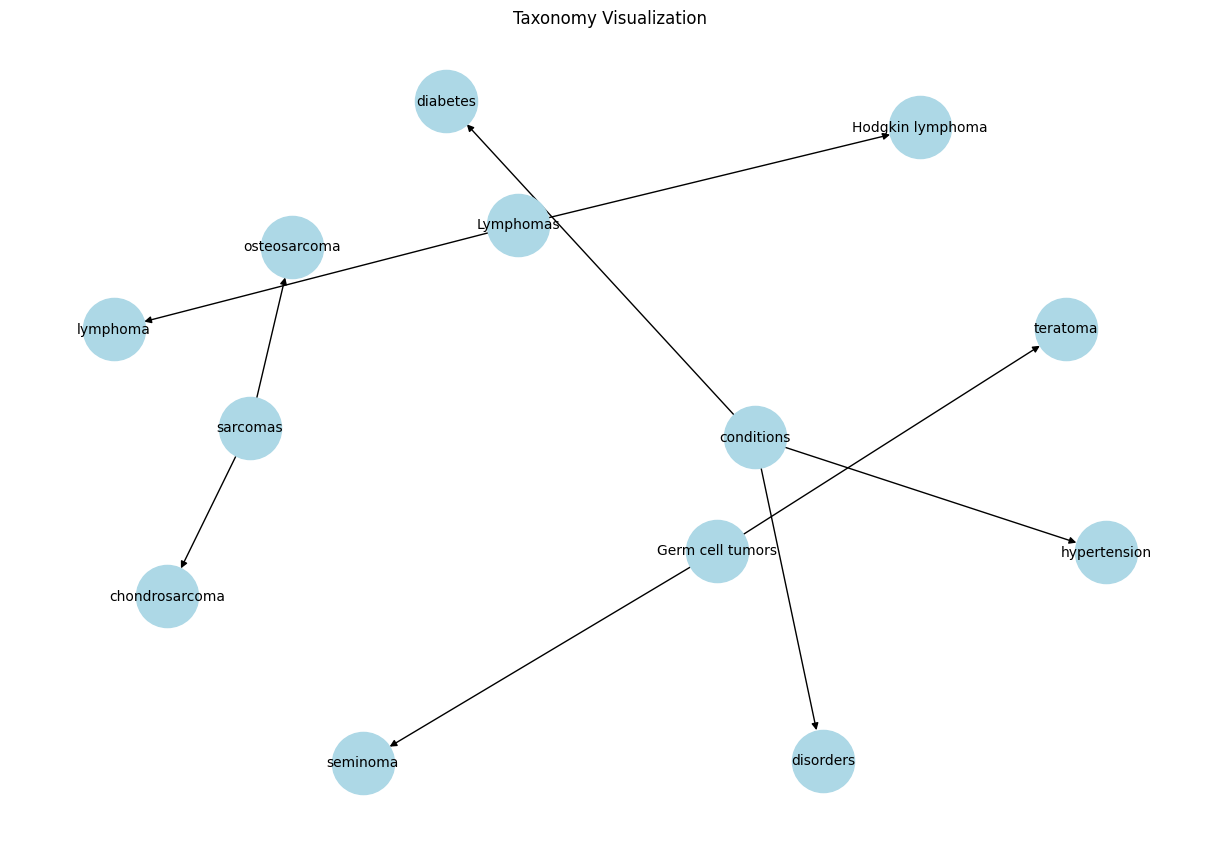

In [6]:
# Extract hyponym relations
hyponym_relations = extract_hyponyms(text)

# Build the taxonomy graph
G = build_taxonomy(hyponym_relations)

# Print the hyponym relations
print("Hyponym Relations:")
for hyponym, hypernym in hyponym_relations:
    print(f"hyponym('{hyponym}', '{hypernym}')")

# Visualize the taxonomy
visualize_taxonomy(G)

### Next Steps
1. Implement Filtering for Domain Focus:
- Add a filtering step to focus the taxonomy on cancer-related terms.
- This can be done by checking if either the hyponym or hypernym contains cancer-related keywords.
2. Expand the Corpus:
- Use a larger and more diverse text corpus, such as PubMed abstracts, to build a more comprehensive taxonomy.
3. Evaluate and Refine the Taxonomy:
- Find metrics of evaluation to compare with the NCIt
